### Task1 Define the Generative Task and Select Approach

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

### Task2 Load and Inspect Data

In [9]:
# Preprocessing definition (tensorization and normalization)
transform = transforms.Compose([
    transforms.ToTensor(),
    # Normalizing with MNIST's mean and standard deviation makes training more stable
    #transforms.Normalize((0.1307,), (0.3081,))
])

# Load the data (automatically downloaded if not present)
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

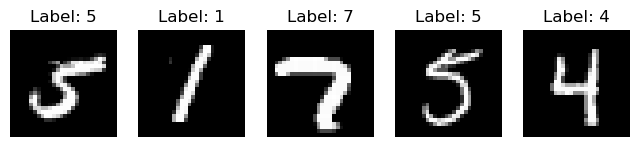

In [10]:
# Pick the first batch of data
images, labels = next(iter(train_loader))

# Display processing
plt.figure(figsize=(8, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    # Convert tensor to numpy and denormalize for display
    img = images[i].numpy().squeeze()
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')
plt.show()

### Task3 Implement and Train a Generative Model

In [11]:
print(images.shape) 
print(images.min(), images.max())

torch.Size([64, 1, 28, 28])
tensor(0.) tensor(1.)


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()
        
        # --- Encoder: 画像から統計量(mu, logvar)を計算 ---
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)    # 平均
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim) # 分散の対数
        
        # --- Decoder: 潜在変数zから画像を再構成 ---
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)
        
    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        # 標準偏差を計算
        std = torch.exp(0.5 * logvar)
        # 標準正規分布からノイズ(epsilon)をサンプリング
        eps = torch.randn_like(std)
        # mu + sigma * eps でサンプリング
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc3(z))
        # MNISTのピクセル値が0-1に正規化されている場合、Sigmoidで出力を0-1に制限
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        # 1. flatten (28x28 -> 784)
        mu, logvar = self.encode(x.view(-1, 784))
        # 2. 潜在変数をサンプリング
        z = self.reparameterize(mu, logvar)
        # 3. 画像を再構成
        return self.decode(z), mu, logvar

In [13]:
def loss_function(recon_x, x, mu, logvar):
    # 1. 再構成誤差 (Reconstruction Loss)
    # 入力と生成された画像がどれだけ似ているか
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    
    # 2. KLダイバージェンス (KL Divergence)
    # 潜在変数の分布が標準正規分布(0, 1)にどれだけ近いか
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return BCE + KLD

In [14]:
device = torch.device("cpu") #"cuda" if torch.cuda.is_available() else "cpu")
# まずは視覚化しやすい 2次元 で作成
model = VAE(latent_dim=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [15]:
def train(epoch):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        
        # Forward pass
        recon_batch, mu, logvar = model(data)
        
        # Lossの計算
        loss = loss_function(recon_batch, data, mu, logvar)
        
        # Backward pass
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
    print(f'====> Epoch: {epoch} Average loss: {train_loss / len(train_loader.dataset):.4f}')
    return train_loss / len(train_loader.dataset)

# 10〜20エポック程度回してみる
losses = []
for epoch in range(1, 11):
    avg_loss = train(epoch)
    losses.append(avg_loss)

====> Epoch: 1 Average loss: 180.9152
====> Epoch: 2 Average loss: 163.6268
====> Epoch: 3 Average loss: 160.0369
====> Epoch: 4 Average loss: 158.0422
====> Epoch: 5 Average loss: 156.7025
====> Epoch: 6 Average loss: 155.5952
====> Epoch: 7 Average loss: 154.6996
====> Epoch: 8 Average loss: 153.8893
====> Epoch: 9 Average loss: 153.1743
====> Epoch: 10 Average loss: 152.4557


### Task4 Generate and Evaluate Outputs

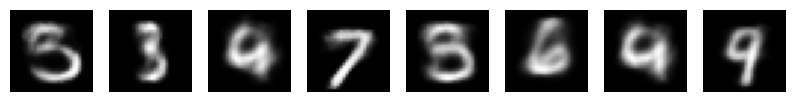

In [16]:
model.eval()
with torch.no_grad():
    # 2次元の潜在空間(z_dim=2)の場合、標準正規分布からサンプリング
    sample = torch.randn(64, 2).to(device)
    sample = model.decode(sample).cpu()
    
    # 最初の8枚を表示
    plt.figure(figsize=(10, 2))
    for i in range(8):
        plt.subplot(1, 8, i+1)
        plt.imshow(sample[i].view(28, 28), cmap='gray')
        plt.axis('off')
    plt.show()

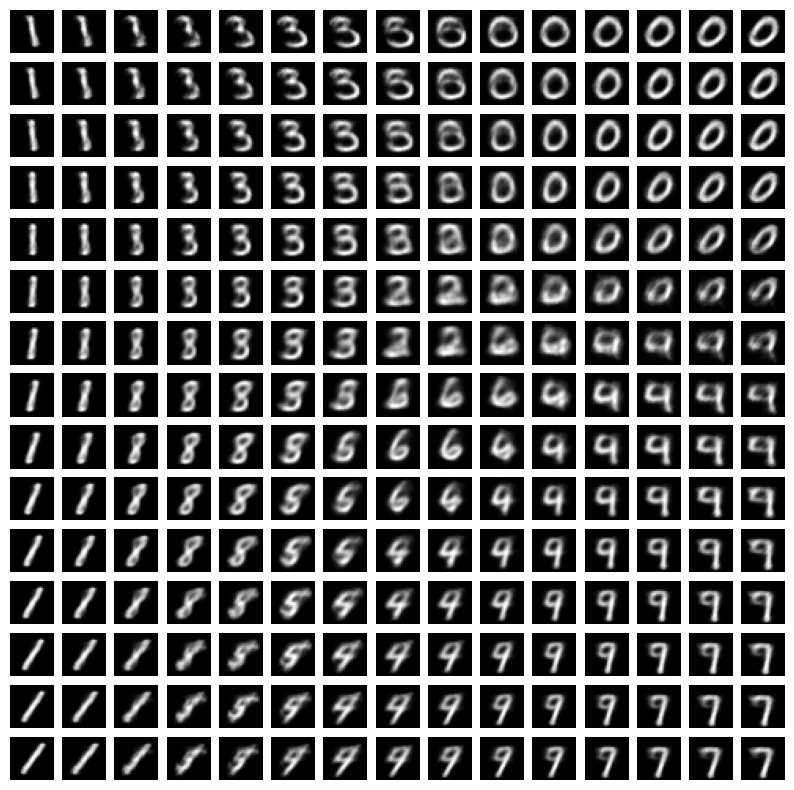

In [17]:
# -2から2までの範囲を15分割してグリッドを作成
n = 15
grid_x = np.linspace(-2, 2, n)
grid_y = np.linspace(-2, 2, n)

plt.figure(figsize=(10, 10))
for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = torch.tensor([[xi, yi]], dtype=torch.float).to(device)
        x_decoded = model.decode(z_sample).cpu().detach()
        digit = x_decoded[0].view(28, 28)
        plt.subplot(n, n, i * n + j + 1)
        plt.imshow(digit, cmap='gray')
        plt.axis('off')
plt.show()